<a href="https://colab.research.google.com/github/OutisAyo/council-classifier-/blob/main/notebooks/11_priority_xgboost_ipynb_.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Machine Learning for Automated Classification and Prioritisation of Local Council Service Requests in the UK
## Notebook 11  XGBoost Classifier (Priority Prediction)

**Author:** Fashina Fuad Ayomide  
**MSc Data Science, University of South Wales**

This notebook builds an XGBoost classifier to predict request priority (HIGH/MEDIUM/LOW) — the final model in our four-algorithm comparison for priority prediction.

## Mounting Google Drive

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


## Importing the libraries

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

## Importing the processed data

In [3]:
processed_dir = '/content/drive/MyDrive/council-classifier/processed'

X_train = np.load(f'{processed_dir}/X_train.npy', allow_pickle=True)
X_test = np.load(f'{processed_dir}/X_test.npy', allow_pickle=True)
y_prio_train = np.load(f'{processed_dir}/y_prio_train.npy', allow_pickle=True)
y_prio_test = np.load(f'{processed_dir}/y_prio_test.npy', allow_pickle=True)

print("Training set size:", len(X_train))
print("Test set size:", len(X_test))

Training set size: 203501
Test set size: 50876


## Encoding the target labels

XGBoost requires numeric class labels rather than text strings.

In [4]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()
y_prio_train_encoded = le.fit_transform(y_prio_train)
y_prio_test_encoded = le.transform(y_prio_test)

print("Priority classes:", le.classes_)
print("\nExample encoding:")
for i in range(5):
    print(f"  {y_prio_train[i]} -> {y_prio_train_encoded[i]}")

Priority classes: ['HIGH' 'LOW' 'MEDIUM']

Example encoding:
  LOW -> 1
  HIGH -> 0
  LOW -> 1
  LOW -> 1
  HIGH -> 0


## Building a pipeline combining vectorisation and classification

In [5]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from xgboost import XGBClassifier

priority_pipeline = Pipeline([
    ('vectorizer', CountVectorizer(max_features=1500)),
    ('classifier', XGBClassifier(n_estimators=100, random_state=0, eval_metric='mlogloss'))
])

priority_pipeline.fit(X_train, y_prio_train_encoded)

Pipeline(steps=[('vectorizer', CountVectorizer(max_features=1500)),
                ('classifier',
                 XGBClassifier(base_score=None, booster=None, callbacks=None,
                               colsample_bylevel=None, colsample_bynode=None,
                               colsample_bytree=None, device=None,
                               early_stopping_rounds=None,
                               enable_categorical=True, eval_metric='mlogloss',
                               feature_types=None, feature_weights=None,
                               gamma=None, grow_policy=None,
                               importance_type=None,
                               interaction_constraints=None, learning_rate=None,
                               max_bin=None, max_cat_threshold=None,
                               max_cat_to_onehot=None, max_delta_step=None,
                               max_depth=None, max_leaves=None,
                               min_child_weight=None, missing=nan,
                               monotone_constraints=None, multi_strategy=None,
                               n_estimators=100, n_jobs=None,
                               num_parallel_tree=None, ...))])

## Predicting the Test set results

In [6]:
y_pred_encoded = priority_pipeline.predict(X_test)
y_pred = le.inverse_transform(y_pred_encoded)

print("Sample predictions vs actual:")
comparison = pd.DataFrame({'Predicted': y_pred[:15], 'Actual': y_prio_test[:15]})
print(comparison)

Sample predictions vs actual:
   Predicted  Actual
0     MEDIUM  MEDIUM
1       HIGH    HIGH
2     MEDIUM  MEDIUM
3       HIGH    HIGH
4        LOW     LOW
5       HIGH    HIGH
6        LOW     LOW
7     MEDIUM  MEDIUM
8       HIGH    HIGH
9     MEDIUM  MEDIUM
10    MEDIUM  MEDIUM
11       LOW     LOW
12    MEDIUM    HIGH
13       LOW  MEDIUM
14    MEDIUM    HIGH


## Making the Confusion Matrix

In [7]:
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

cm = confusion_matrix(y_prio_test, y_pred)
print("Confusion Matrix:")
print(cm)

print("\nAccuracy:", accuracy_score(y_prio_test, y_pred))

Confusion Matrix:
[[ 4320  3114  5583]
 [ 1025 19496  3528]
 [ 1361  2743  9706]]

Accuracy: 0.658896139633619


## Classification Report

In [8]:
print(classification_report(y_prio_test, y_pred))

              precision    recall  f1-score   support

        HIGH       0.64      0.33      0.44     13017
         LOW       0.77      0.81      0.79     24049
      MEDIUM       0.52      0.70      0.59     13810

    accuracy                           0.66     50876
   macro avg       0.64      0.62      0.61     50876
weighted avg       0.67      0.66      0.65     50876



## Visualising the Confusion Matrix

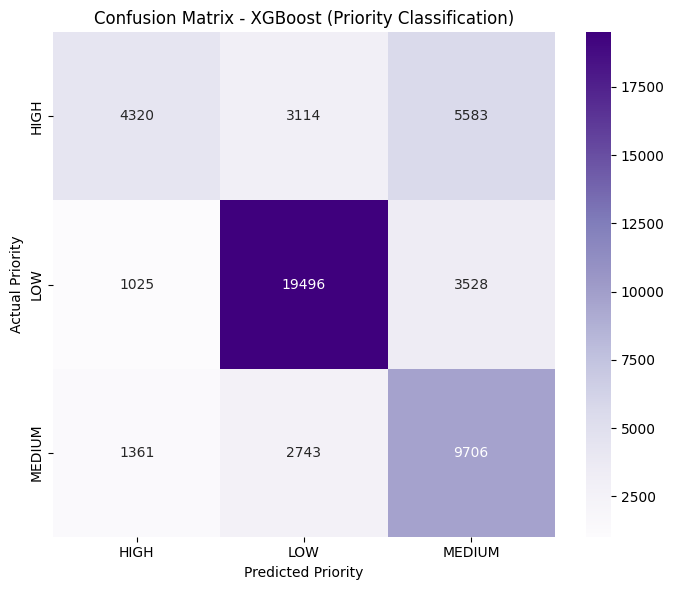

In [9]:
plt.figure(figsize=(7, 6))
unique_labels = sorted(set(y_prio_test))

sns.heatmap(cm, annot=True, fmt='d', cmap='Purples',
            xticklabels=unique_labels, yticklabels=unique_labels)
plt.title('Confusion Matrix - XGBoost (Priority Classification)')
plt.xlabel('Predicted Priority')
plt.ylabel('Actual Priority')
plt.tight_layout()
plt.show()

## Checking where urgency-related words rank in importance

We check whether explicit urgency vocabulary (e.g. "urgent", "emergency", "dangerous") appears in the vocabulary at all, and how strongly it contributes compared to department-associated words.

In [10]:
importances = priority_pipeline.named_steps['classifier'].feature_importances_
feature_names = priority_pipeline.named_steps['vectorizer'].get_feature_names_out()

importance_df = pd.DataFrame({
    'word': feature_names,
    'importance': importances
}).sort_values('importance', ascending=False).reset_index(drop=True)

urgency_words = ['urgent', 'emergency', 'dangerous', 'hazard', 'immediate', 'risk', 'severe']

print("Top 15 most important words overall:")
print(importance_df.head(15))

print("\nRanking of urgency-related words (if present in vocabulary):")
for word in urgency_words:
    match = importance_df[importance_df['word'] == word]
    if not match.empty:
        rank = match.index[0] + 1
        print(f"  '{word}': rank {rank} of {len(importance_df)}, importance = {match['importance'].values[0]:.5f}")
    else:
        print(f"  '{word}': not present in top 1500 vocabulary")

Top 15 most important words overall:
          word  importance
0      request    0.140886
1   unreported    0.102792
2          non    0.100256
3       driver    0.031766
4    recycling    0.031130
5         rats    0.029847
6     domestic    0.027480
7       issues    0.027477
8       street    0.027098
9    exemption    0.021544
10         bag    0.021106
11       trade    0.018476
12        bags    0.017460
13       scene    0.017353
14         rec    0.015908

Ranking of urgency-related words (if present in vocabulary):
  'urgent': rank 95 of 579, importance = 0.00085
  'emergency': not present in top 1500 vocabulary
  'dangerous': rank 112 of 579, importance = 0.00066
  'hazard': rank 239 of 579, importance = 0.00012
  'immediate': not present in top 1500 vocabulary
  'risk': not present in top 1500 vocabulary
  'severe': not present in top 1500 vocabulary


## Appending results to the priority comparison file

In [12]:
from sklearn.metrics import f1_score

results_path = '/content/drive/MyDrive/council-classifier/processed/priority_model_results.csv'
results_df = pd.read_csv(results_path)

new_result = {
    'model': 'XGBoost',
    'accuracy': accuracy_score(y_prio_test, y_pred),
    'f1_macro': f1_score(y_prio_test, y_pred, average='macro'),
    'f1_weighted': f1_score(y_prio_test, y_pred, average='weighted')
}

results_df = pd.concat([results_df, pd.DataFrame([new_result])], ignore_index=True)
results_df.to_csv(results_path, index=False)

print(results_df)

                 model  accuracy  f1_macro  f1_weighted
0          Naive Bayes  0.627801  0.587242     0.625258
1  Logistic Regression  0.657147  0.607315     0.647002
2        Random Forest  0.658857  0.609522     0.648884
3              XGBoost  0.658896  0.607438     0.646674
